### Old notebook (not updated)

- Notebook was merged with `evals.ipynb`
- The notebook will be deleted once the code for smoothed probabilities has been migrated

In [43]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, PredefinedSplit

from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline, eval_combination_matrix

from rital_nlp_project.presidents.utils import smooth_predictions, concat_seq_by_class, split_for_cv
from rital_nlp_project.presidents.metrics import scoring

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")

In [49]:
max_features = 5000
min_df = 5
max_df = 0.5

vectorizer_list = [
    CountVectorizer(analyzer="char", ngram_range=(1, 1), max_features=max_features),
    CountVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),

    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    #SVC(kernel="rbf")
]

### Separated phrases

In [45]:
# Train/test split
split_idx = int(len(texts_pres) * 0.8)

X_train = texts_pres[:split_idx]
X_test  = texts_pres[split_idx:]
y_train = classes_pres[:split_idx]
y_test  = classes_pres[split_idx:]

In [118]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([-1,  1]), array([ 6360, 39570])),
 (array([-1,  1]), array([ 1163, 10320])))

In [46]:
#results = eval_combination_matrix(X_train, y_train, X_test, y_test, vectorizer_list, classifier_list)
#results.to_csv("out/baseline_eval_matrix_pres.csv", index=False)
results = pd.read_csv("out/baseline_eval_matrix_pres.csv")

Text(0.5, 1.0, 'F1-score')

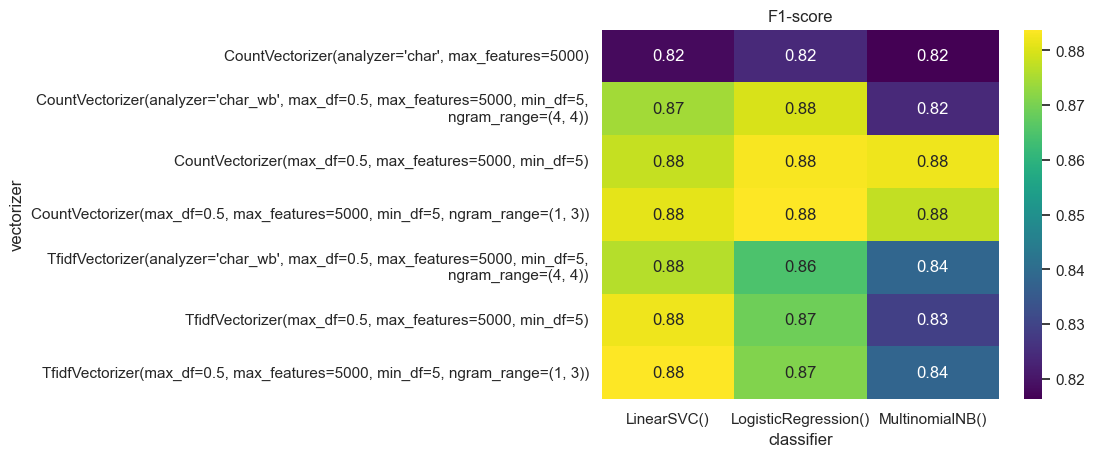

In [47]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="f1"), annot=True, cmap="viridis")
plt.title("F1-score")

Text(0.5, 1.0, 'Train time')

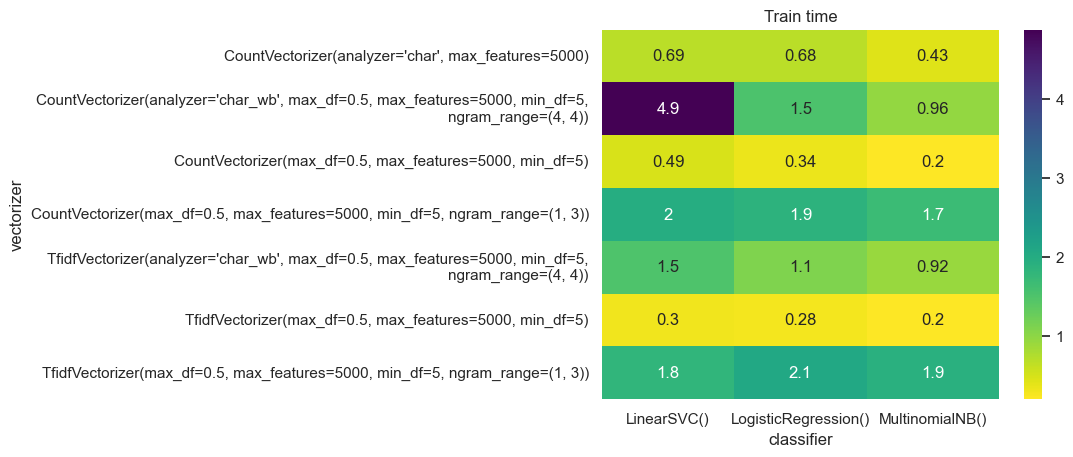

In [6]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="train_time"), annot=True, cmap="viridis_r")
plt.title("Train time")

### Try smoothing

In [ ]:
gs = split_for_cv(classes_pres, 5)
train_idx, test_idx = next(gs.split())

In [130]:
# labels, counts = np.unique(y_train, return_counts=True)
# labels, counts

In [50]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(analyzer="word", ngram_range=(1, 1), min_df=min_df, max_df=max_df, max_features=max_features)),
    ("classifier", MultinomialNB())
])
#X_train_concat, y_train_concat = concat_seq_by_class(X_train, y_train)
eval_pipeline(texts_pres, classes_pres, X_train, y_train, X_test, y_test, pipeline, scoring, False, True)

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, max_features=5000, min_df=5)
  classifier: MultinomialNB()
Training time: 0.309 seconds
Inference time: 0.051 seconds
Test accuracy: 0.8871
Test f1: 0.9367
Test roc_auc: 0.7167
              precision    recall  f1-score   support

          -1       0.45      0.50      0.47      1163
           1       0.94      0.93      0.94     10320

    accuracy                           0.89     11483
   macro avg       0.70      0.72      0.71     11483
weighted avg       0.89      0.89      0.89     11483




{'vectorizer': CountVectorizer(max_df=0.5, max_features=5000, min_df=5),
 'classifier': MultinomialNB(),
 'accuracy': 0.8870504223634939,
 'f1': 0.936728620908337,
 'roc_auc': 0.7166694578309237}

In [51]:
pipeline.fit(X_train, y_train)
preds_raw = pipeline.predict(X_test)
preds_probas = pipeline.predict_proba(X_test)
preds_probas_smooth = smooth_predictions(preds_probas, sigma=1)
preds_smooth = pipeline.classes_[np.argmax(preds_probas_smooth, axis=1)]

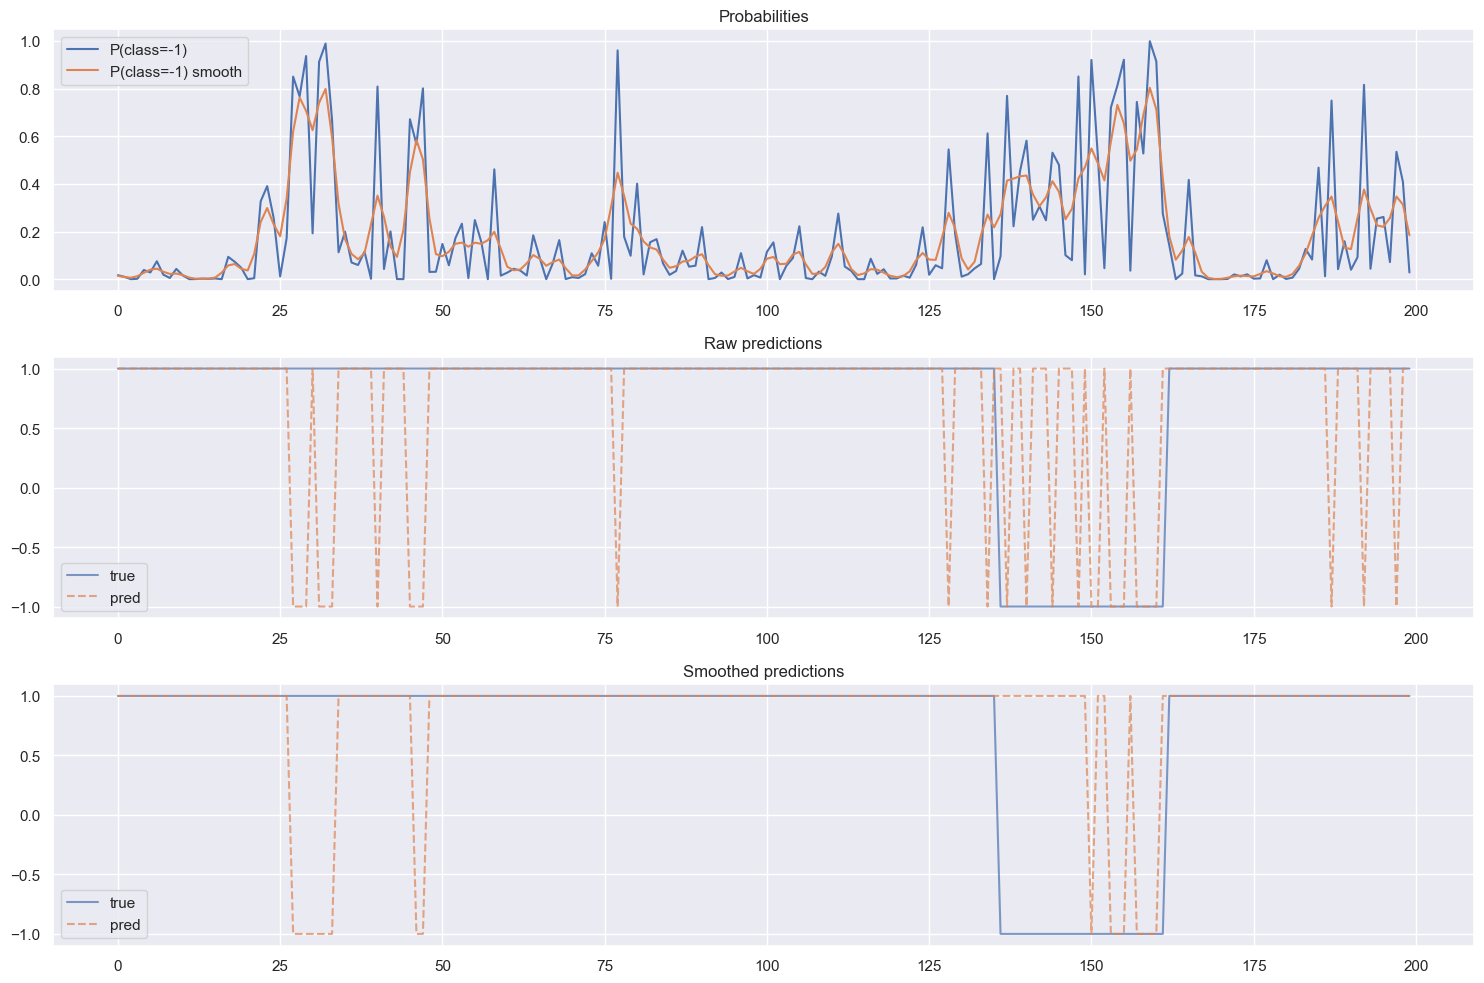

In [52]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))
limit = 200

ax1.set_title("Probabilities")
sns.lineplot(preds_probas[:limit, 0], label=f"P(class={pipeline.classes_[0]})", ax=ax1)
sns.lineplot(preds_probas_smooth[:limit, 0], label=f"P(class={pipeline.classes_[0]}) smooth", ax=ax1)

ax2.set_title("Raw predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax2, alpha=0.7)
sns.lineplot(preds_raw[:limit], label="pred", ax=ax2, alpha=0.7, linestyle="--")

ax3.set_title("Smoothed predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax3, alpha=0.7)
sns.lineplot(preds_smooth[:limit], label="pred", ax=ax3, alpha=0.7, linestyle="--")

plt.tight_layout()

In [53]:
print(f1_score(y_test, preds_raw))
print(f1_score(y_test, preds_smooth))

print(classification_report(y_test, preds_raw))
print(classification_report(y_test, preds_smooth))

0.936728620908337
0.9616611896937658
              precision    recall  f1-score   support

          -1       0.45      0.50      0.47      1163
           1       0.94      0.93      0.94     10320

    accuracy                           0.89     11483
   macro avg       0.70      0.72      0.71     11483
weighted avg       0.89      0.89      0.89     11483

              precision    recall  f1-score   support

          -1       0.72      0.50      0.59      1163
           1       0.95      0.98      0.96     10320

    accuracy                           0.93     11483
   macro avg       0.83      0.74      0.78     11483
weighted avg       0.92      0.93      0.92     11483

